# HireSense - Model Comparison & Analytics

This notebook compares Model A (Base Model) vs Model B (Fine-Tuned Model) across all metrics and exports visualizations and results for the dashboard.

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load metrics
with open('../data/base_metrics.json', 'r') as f:
    base_metrics = json.load(f)

with open('../data/fine_tuned_metrics.json', 'r') as f:
    tuned_metrics = json.load(f)

print("Base Metrics Loaded:", base_metrics)
print("Tuned Metrics Loaded:", tuned_metrics)

Base Metrics Loaded: {'Precision': 0.15632219388177948, 'Recall': 1.0, 'F1 Score': 0.26849737981316923, 'Top-K Accuracy': 1.0, 'Mean Similarity Score': 0.7453082862185009, 'Ranking Accuracy (MRR)': 1.0}
Tuned Metrics Loaded: {'Precision': 0.6232492997198881, 'Recall': 1.0, 'F1 Score': 0.7414102564102564, 'Top-K Accuracy': 1.0, 'Mean Similarity Score': 0.874830969234011, 'Ranking Accuracy (MRR)': 1.0}


In [2]:
# Build Comparison DataFrame
data = {
    'Metric': list(base_metrics.keys()),
    'Base Model (Model A)': list(base_metrics.values()),
    'Fine-Tuned Model (Model B)': list(tuned_metrics.values())
}
df = pd.DataFrame(data)
df['Improvement'] = df['Fine-Tuned Model (Model B)'] - df['Base Model (Model A)']

print("--- Model Comparison Table ---")
print(df.to_string(index=False))

# Save comparison metrics for the dashboard
comparison_metrics = []
for key in base_metrics.keys():
    comparison_metrics.append({
        "metric": key,
        "base": base_metrics[key],
        "tuned": tuned_metrics[key],
        "improvement": tuned_metrics[key] - base_metrics[key]
    })

os.makedirs('../app/static', exist_ok=True)
with open('../app/static/metrics_comparison.json', 'w') as f:
    json.dump(comparison_metrics, f, indent=2)
print("metrics_comparison.json written for dashboard!")

--- Model Comparison Table ---
                Metric  Base Model (Model A)  Fine-Tuned Model (Model B)  Improvement
             Precision              0.156322                    0.623249     0.466927
                Recall              1.000000                    1.000000     0.000000
              F1 Score              0.268497                    0.741410     0.472913
        Top-K Accuracy              1.000000                    1.000000     0.000000
 Mean Similarity Score              0.745308                    0.874831     0.129523
Ranking Accuracy (MRR)              1.000000                    1.000000     0.000000
metrics_comparison.json written for dashboard!


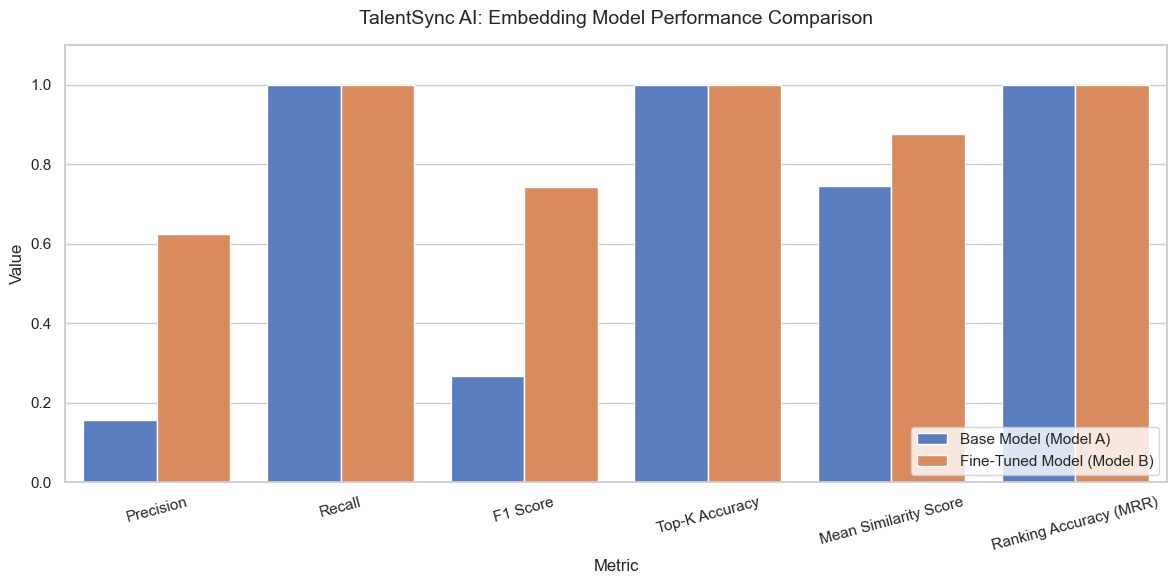

model_comparison.png saved!


In [3]:
# Create Comparison Bar Charts
df_melted = pd.melt(df, id_vars=['Metric'], value_vars=['Base Model (Model A)', 'Fine-Tuned Model (Model B)'], var_name='Model', value_name='Score')

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='muted')
plt.title('HireSense: Embedding Model Performance Comparison', fontsize=14, pad=15)
plt.xticks(rotation=15)
plt.ylim(0, 1.1)
plt.ylabel('Value')
plt.legend(loc='lower right')
plt.tight_layout()

os.makedirs('../app/static/charts', exist_ok=True)
plt.savefig('../app/static/charts/model_comparison.png', dpi=300)
plt.show()
print("model_comparison.png saved!")